In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nicapotato/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv


In [2]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [4]:
file_path = "/kaggle/input/datasets/nicapotato/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

Columns:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Missing values:


Title                      3810
Review Text                 845
Department Name              14
Class Name                   14
Division Name                14
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
dtype: int64

In [6]:
required_columns = ["Title", "Review Text", "Recommended IND"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df[required_columns].copy()

data["Title"] = data["Title"].fillna("")
data["Review Text"] = data["Review Text"].fillna("")

data["combined_text"] = (
    data["Title"].astype(str).str.strip()
    + " "
    + data["Review Text"].astype(str).str.strip()
).str.strip()

# Remove rows without review text or target label
data = data[
    (data["combined_text"].str.len() > 0)
    & (data["Recommended IND"].notna())
].copy()

data["Recommended IND"] = data["Recommended IND"].astype(int)

print("Prepared dataset shape:", data.shape)
display(data.head())

Prepared dataset shape: (22642, 4)


,Title,Review Text,Recommended IND,combined_text
0,,Absolutely wonderful - silky and sexy and comf...,1,Absolutely wonderful - silky and sexy and comf...
1,,Love this dress! it's sooo pretty. i happene...,1,Love this dress! it's sooo pretty. i happene...
2,Some major design flaws,I had such high hopes for this dress and reall...,0,Some major design flaws I had such high hopes ...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",1,"My favorite buy! I love, love, love this jumps..."
4,Flattering shirt,This shirt is very flattering to all due to th...,1,Flattering shirt This shirt is very flattering...


In [7]:
class_distribution = (
    data["Recommended IND"]
    .value_counts()
    .rename(index={0: "Negative / Not Recommended", 1: "Positive / Recommended"})
    .to_frame("Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"] / class_distribution["Count"].sum() * 100
).round(2)

display(class_distribution)

,Count,Percentage
Recommended IND,,
Positive / Recommended,18541,81.89
Negative / Not Recommended,4101,18.11


In [8]:
stop_words = set(stopwords.words("english"))

# Keep negation words because they can be important for sentiment
for word in ["not", "no", "nor", "never"]:
    stop_words.discard(word)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Clean and lemmatize review text.
    """
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove digits
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenize
    tokens = re.findall(r"\b[a-z]{2,}\b", text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(tokens)

In [9]:
data["clean_text"] = data["combined_text"].apply(preprocess_text)

# Remove rows that became empty after preprocessing
data = data[data["clean_text"].str.strip().str.len() > 0].copy()

print("Number of usable reviews:", len(data))

display(
    data[
        ["combined_text", "clean_text", "Recommended IND"]
    ].head()
)

Number of usable reviews: 22642


,combined_text,clean_text,Recommended IND
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,1
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store gla...,1
2,Some major design flaws I had such high hopes ...,major design flaw high hope dress really wante...,0
3,"My favorite buy! I love, love, love this jumps...",favorite buy love love love jumpsuit fun flirt...,1
4,Flattering shirt This shirt is very flattering...,flattering shirt shirt flattering due adjustab...,1


In [10]:
X = data["clean_text"]
y = data["Recommended IND"]

print("Feature rows:", X.shape[0])
print("Target distribution:")
print(y.value_counts())

Feature rows: 22642
Target distribution:
Recommended IND
1    18541
0     4101
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 18113
Testing samples: 4529


In [12]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Testing TF-IDF matrix shape:", X_test_tfidf.shape)

Training TF-IDF matrix shape: (18113, 15000)
Testing TF-IDF matrix shape: (4529, 15000)


In [13]:
feature_names = tfidf.get_feature_names_out()

tfidf_sample = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

# Display only features that occur in the first five documents
tfidf_sample = tfidf_sample.loc[:, (tfidf_sample != 0).any(axis=0)]

display(tfidf_sample.iloc[:, :30])

,abt,appears,appears online,area,beach,beautiful,beautiful online,cheap,comfy,comfy versatile,...,definite,didnt,different,disappointing,even,fabric,fabric different,fabric soft,felt,felt like
0,0.000000,0.134558,0.178525,0.000000,0.000000,0.112258,0.201485,0.123762,0.000000,0.000000,...,0.169693,0.000000,0.099366,0.13792,0.079823,0.062309,0.204242,0.000000,0.104009,0.132287
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.210951,0.000000,0.00000,0.090241,0.070442,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.319084,0.000000,0.000000,0.000000,0.207343,0.447695,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140986,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.095308,0.000000,0.185749,0.000000,0.000000
4,0.209138,0.000000,0.000000,0.192238,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    solver="liblinear"
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [15]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
binary_f1 = f1_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1-score: Positive Class",
        "Macro F1-score",
        "Weighted F1-score"
    ],
    "Score": [
        accuracy,
        binary_f1,
        macro_f1,
        weighted_f1
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Accuracy,0.8885
1,F1-score: Positive Class,0.9293
2,Macro F1-score,0.8327
3,Weighted F1-score,0.8943


In [16]:
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Negative / Not Recommended",
        "Positive / Recommended"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))

,precision,recall,f1-score,support
Negative / Not Recommended,0.6441,0.8585,0.7360,820.0000
Positive / Recommended,0.9662,0.8951,0.9293,3709.0000
accuracy,0.8885,0.8885,0.8885,0.8885
macro avg,0.8052,0.8768,0.8327,4529.0000
weighted avg,0.9079,0.8885,0.8943,4529.0000


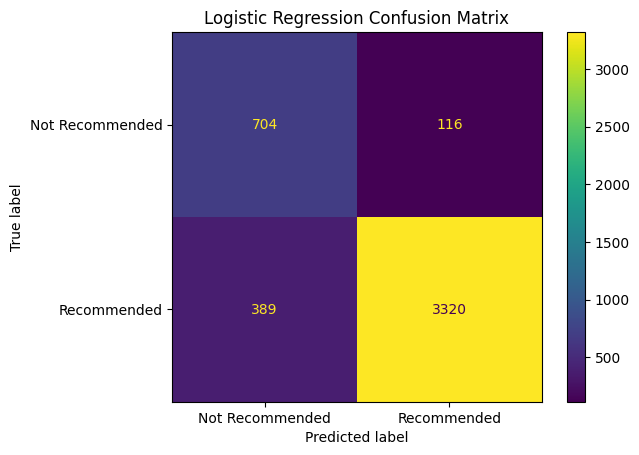

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Recommended",
        "Recommended"
    ]
)

disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [18]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

top_n = 10

positive_indices = np.argsort(coefficients)[-top_n:][::-1]
negative_indices = np.argsort(coefficients)[:top_n]

top_positive = pd.DataFrame({
    "Class": "Positive / Recommended",
    "Word or Phrase": feature_names[positive_indices],
    "Coefficient": coefficients[positive_indices]
})

top_negative = pd.DataFrame({
    "Class": "Negative / Not Recommended",
    "Word or Phrase": feature_names[negative_indices],
    "Coefficient": coefficients[negative_indices]
})

top_words = pd.concat(
    [top_positive, top_negative],
    ignore_index=True
)

top_words["Coefficient"] = top_words["Coefficient"].round(4)

display(top_words)

,Class,Word or Phrase,Coefficient
0,Positive / Recommended,love,7.5581
1,Positive / Recommended,perfect,6.2370
2,Positive / Recommended,great,5.9341
3,Positive / Recommended,comfortable,4.8974
4,Positive / Recommended,unique,4.2915
5,Positive / Recommended,soft,4.2219
6,Positive / Recommended,little,4.0336
7,Positive / Recommended,flattering,3.5521
8,Positive / Recommended,compliment,3.3213
9,Positive / Recommended,beautiful,3.1431


In [19]:
top_words_table = pd.DataFrame({
    "Positive / Recommended": feature_names[positive_indices],
    "Positive Coefficient": coefficients[positive_indices],
    "Negative / Not Recommended": feature_names[negative_indices],
    "Negative Coefficient": coefficients[negative_indices]
})

top_words_table["Positive Coefficient"] = (
    top_words_table["Positive Coefficient"].round(4)
)

top_words_table["Negative Coefficient"] = (
    top_words_table["Negative Coefficient"].round(4)
)

display(top_words_table)

,Positive / Recommended,Positive Coefficient,Negative / Not Recommended,Negative Coefficient
0,love,7.5581,disappointed,-6.7886
1,perfect,6.2370,wanted love,-5.8335
2,great,5.9341,not,-5.3489
3,comfortable,4.8974,returning,-4.9087
4,unique,4.2915,returned,-4.8415
5,soft,4.2219,not flattering,-4.8359
6,little,4.0336,unflattering,-4.7260
7,flattering,3.5521,huge,-4.6877
8,compliment,3.3213,return,-4.2266
9,beautiful,3.1431,cheap,-4.1157


In [20]:
def predict_sentiment(review):
    cleaned_review = preprocess_text(review)
    review_vector = tfidf.transform([cleaned_review])

    prediction = model.predict(review_vector)[0]
    probabilities = model.predict_proba(review_vector)[0]

    label = (
        "Positive / Recommended"
        if prediction == 1
        else "Negative / Not Recommended"
    )

    return {
        "review": review,
        "cleaned_review": cleaned_review,
        "prediction": label,
        "negative_probability": round(float(probabilities[0]), 4),
        "positive_probability": round(float(probabilities[1]), 4)
    }

example_reviews = [
    "I absolutely love this dress. It fits perfectly and the material is beautiful.",
    "The item was poorly made, too small, and looked nothing like the picture."
]

for review in example_reviews:
    print(predict_sentiment(review))
    print("-" * 80)

{'review': 'I absolutely love this dress. It fits perfectly and the material is beautiful.', 'cleaned_review': 'absolutely love dress fit perfectly material beautiful', 'prediction': 'Positive / Recommended', 'negative_probability': 0.0278, 'positive_probability': 0.9722}
--------------------------------------------------------------------------------
{'review': 'The item was poorly made, too small, and looked nothing like the picture.', 'cleaned_review': 'item poorly made small looked nothing like picture', 'prediction': 'Negative / Not Recommended', 'negative_probability': 0.9577, 'positive_probability': 0.0423}
--------------------------------------------------------------------------------


In [21]:
print("TEXT SENTIMENT CLASSIFICATION SUMMARY")
print("-" * 50)
print(f"Number of reviews used: {len(data):,}")
print(f"Number of TF-IDF features: {X_train_tfidf.shape[1]:,}")
print("Classifier: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print(f"Positive-class F1-score: {binary_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

TEXT SENTIMENT CLASSIFICATION SUMMARY
--------------------------------------------------
Number of reviews used: 22,642
Number of TF-IDF features: 15,000
Classifier: Logistic Regression
Accuracy: 0.8885
Positive-class F1-score: 0.9293
Macro F1-score: 0.8327
Weighted F1-score: 0.8943


## Conclusion

A sentiment-classification pipeline was developed using the review title and
review text from the Women's Clothing E-Commerce Reviews dataset. The text was
converted to lowercase, cleaned of punctuation and non-alphabetic characters,
tokenized, stripped of stopwords, and lemmatized.

TF-IDF was used to transform the cleaned reviews into numerical features.
A Logistic Regression classifier was trained to predict whether a reviewer
recommended the product.

The model achieved an accuracy of **88.85%** and a positive-class F1-score
of **92.93%** on the test set. The coefficient analysis also identified the
words and phrases most strongly associated with recommended and
non-recommended products.